In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
# 1. 데이터 생성 (랜덤 숫자 시퀀스)
data = np.array([i for i in range(1, 21)])  # 1부터 20까지의 숫자
timesteps = 3  # 타임스텝 길이, sequence lenght와 같은 개념

In [3]:
x_data = []
y_data = []

In [4]:
# 타임스텝에 따라 입력 데이터와 출력 데이터 생성
for i in range(len(data) - timesteps):
    x_data.append(data[i:i + timesteps])  # 입력 (3개의 숫자)
    y_data.append(data[i + timesteps])   # 출력 (다음 숫자)

x_data = np.array(x_data).reshape(-1, timesteps, 1)  # (샘플 수, 타임스텝, 피처 수)
y_data = np.array(y_data)  # 출력값

In [5]:
# 2. LSTM 모델 정의
model = Sequential([
    LSTM(10, input_shape=(timesteps, 1)),  # LSTM 레이어 (유닛: 10)
    Dense(1)  # 출력 레이어
])

c:\Python310\projects\ydataprofiling\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(optimizer='adam', loss='mse')

In [7]:
# 3. 모델 학습
model.fit(x_data, y_data, epochs=1000, verbose=1)  # 100번 반복 학습

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 159.1705
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 158.8770
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 158.5822
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 158.2858
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 157.9881
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 157.6888
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 157.3880
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 157.0856
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 156.7815
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 156.4758
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 156.1684
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 155.8593
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 155.5483
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 155.2355
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58m

In [8]:
# 4. 예측 테스트
test_input = np.array([18, 19, 20]).reshape(1, timesteps, 1)  # 입력 예시
predicted_value = model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


In [10]:
# 결과 출력
print("입력 데이터:", test_input.flatten()) # flatten함수 : [[[18],[19],[20]]] --> [18,19,20]
print("예측 값:", predicted_value[0][0])

입력 데이터: [18 19 20]
예측 값: 11.495578


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [13]:
file_path = "dataset/jena_climate_2009.csv"
data = pd.read_csv(file_path)

In [14]:
data.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [15]:
data.shape

(21743, 15)

In [16]:
temperature = data['T (degC)'].values

In [17]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(temperature.reshape(-1, 1))

In [18]:
# 데이터셋 생성 함수 : look_back(sequence length와 같은 의미)
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i + look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [19]:
look_back = 60  # 과거 60분 데이터를 기반으로 예측
X, y = create_dataset(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # RNN 입력 형태

In [20]:
X.shape

(21683, 60, 1)

In [21]:
# 데이터 분리
train_size = int(len(X) * 0.8)  # 80% 학습 데이터
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [22]:
# 3. RNN 모델 구성
model = Sequential([
    SimpleRNN(50, return_sequences=False, input_shape=(X.shape[1], 1)),  # 50(뉴런 즉 메모리유닛수), return_sequence=False(마지막시점 출력만 반환)
    Dense(1)
])

c:\Python310\projects\ydataprofiling\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [24]:
# 4. 모델 학습
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0064 - val_loss: 6.0355e-04
Epoch 2/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.8113e-04 - val_loss: 2.2757e-04
Epoch 3/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.4813e-04 - val_loss: 1.7618e-04
Epoch 4/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.2148e-04 - val_loss: 1.1637e-04
Epoch 5/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 9.8454e-05 - val_loss: 9.8454e-05
Epoch 6/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8.6708e-05 - val_loss: 1.1421e-04
Epoch 7/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.3685e-05 - val_loss: 9.9678e-05
Epoch 8/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.1063e-05 - val_loss: 7.5900e-05
Epoch 9/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 5.1421e-05 - val_loss: 9.6588e-05
Epoch 10/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.4686e-05 - val_loss: 9.4230e-05
Epoch 11/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 4.

In [25]:
# 5. 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # 정규화 복원

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [26]:
# 실제 값 복원
actual_values = scaler.inverse_transform(y_test.reshape(-1, 1))

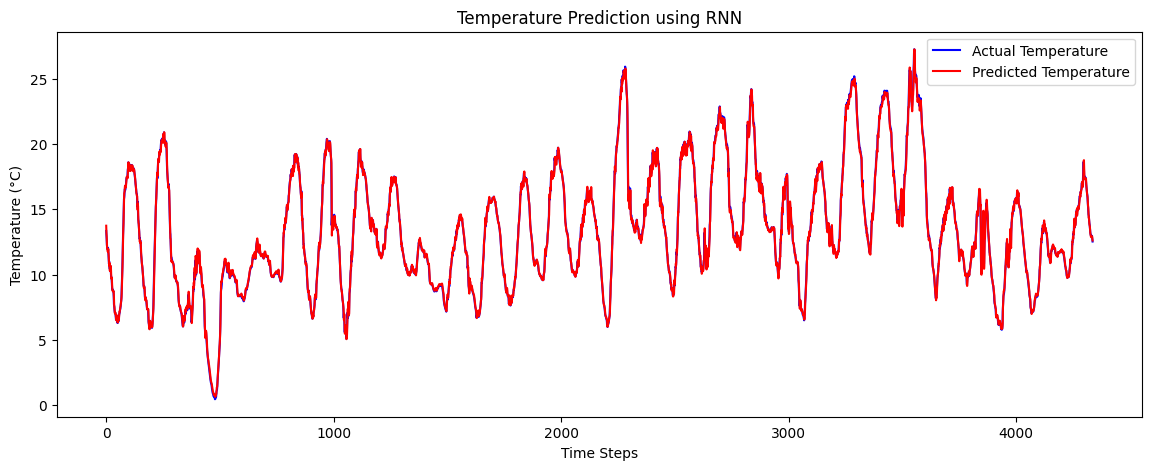

In [27]:
# 6. 시각화
plt.figure(figsize=(14, 5))
plt.plot(actual_values, label="Actual Temperature", color='blue')
plt.plot(predictions, label="Predicted Temperature", color='red')
plt.title('Temperature Prediction using RNN')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

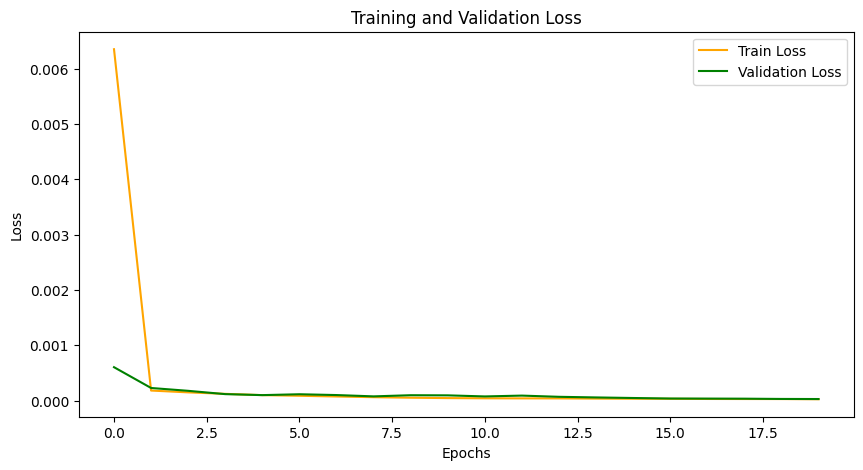

In [28]:
# 7. 학습 손실 시각화
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [29]:
# 증권데이터 수집 라이브러리 설치 :  pip install yfinance
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [30]:
# 1. 데이터 수집
ticker = "AAPL"  # 예: 애플 주식
data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
data = data[['Close']]  # 종가만 사용

[*********************100%***********************]  1 of 1 completed


In [31]:
data.head()

Price,Close
Ticker,AAPL
Date,
2015-01-02,24.214897
2015-01-05,23.532717
2015-01-06,23.534943
2015-01-07,23.864946
2015-01-08,24.781895


In [32]:
# 2. 데이터 전처리
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [33]:
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i + look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [34]:
look_back = 60  # 과거 60일 데이터로 예측
X, y = create_dataset(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # LSTM 입력 형태 (샘플수, 시퀀스 길이, 피처수)

In [48]:
# 3. 모델 구성
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)),  # input_shape(시퀀스 길이, 피처수)
    LSTM(32, dropout=0.2),
    Dense(1)
])

In [49]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [50]:
# 4. 모델 학습
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [51]:
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/20


56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0016 - val_loss: 0.0045
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0060 - val_loss: 0.0096
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0038 - val_loss: 0.0068
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0020 - val_loss: 0.0027
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 8.7291e-04 - val_loss: 0.0013
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 8.2443e-04 - val_loss: 0.0012
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 5.9745e-04 - val_loss: 0.0012
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 6.1058e-04 - val_loss: 0.0011
Epoch 12/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss

In [52]:
# 5. 예측 및 시각화
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))  # 2차원 배열로 표시 (샘플수, 1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [53]:
# 실제 값 복원
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

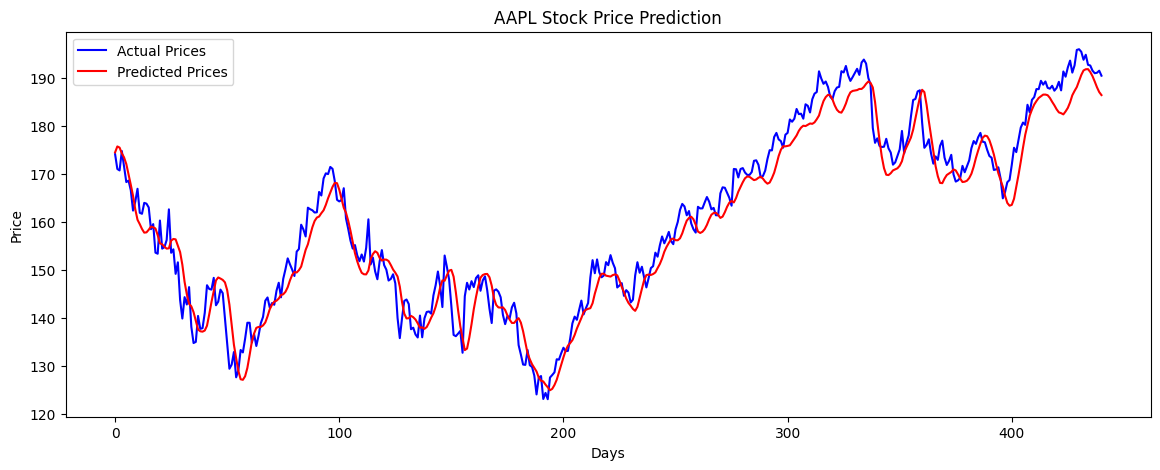

In [42]:
# 시각화
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label="Actual Prices", color='blue')
plt.plot(predictions, label="Predicted Prices", color='red')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

In [99]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [100]:
# 데이터 불러오기
data_path = 'dataset/airline.csv'  # 데이터 경로
df = pd.read_csv(data_path)

In [101]:
# 데이터 확인
print(df.head())

         date  count
0  1949-01-01    112
1  1949-02-01    118
2  1949-03-01    132
3  1949-04-01    129
4  1949-05-01    121


In [102]:
# 날짜(Date)와 탑승객 수(count) 열의 이름 설정 및 변환
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

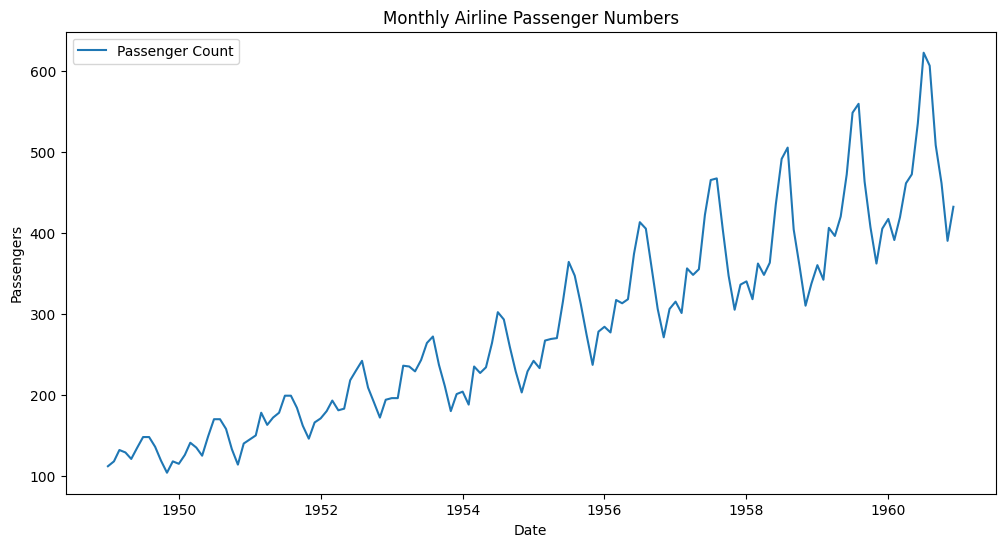

In [103]:
# 데이터 시각화
plt.figure(figsize=(12, 6))
plt.plot(df['count'], label='Passenger Count')
plt.title('Monthly Airline Passenger Numbers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

In [104]:
# 데이터 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['count']])

In [105]:
# 데이터셋 분리 (학습 데이터와 테스트 데이터)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [106]:
# 시계열 데이터셋 생성 함수
def create_dataset(data, time_step=12):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

In [107]:
time_step = 12  # 12개월 단위로 예측
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [108]:
# LSTM 입력에 맞게 데이터 형태 변경
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
# LSTM 모델 생성
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(time_step, 1)),
    LSTM(32,dropout=0.2,  return_sequences=False),
    Dense(25),
    Dense(1)
])

c:\Python310\projects\ydataprofiling\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [110]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

In [111]:
# 모델 학습
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1, shuffle=False)

Epoch 1/50


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - loss: 0.0850 - val_loss: 0.2665
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0274 - val_loss: 0.0825
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0075 - val_loss: 0.0226
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0216 - val_loss: 0.0232
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0152 - val_loss: 0.0364
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0108 - val_loss: 0.0580
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0104 - val_loss: 0.0535
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0083 - val_loss: 0.0353
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0075 - val_loss: 0.0254
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0084 - val_loss: 0.0243
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0078 - val_loss: 0.0267
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0070 - val_loss: 0.0296
Epoch 13/50

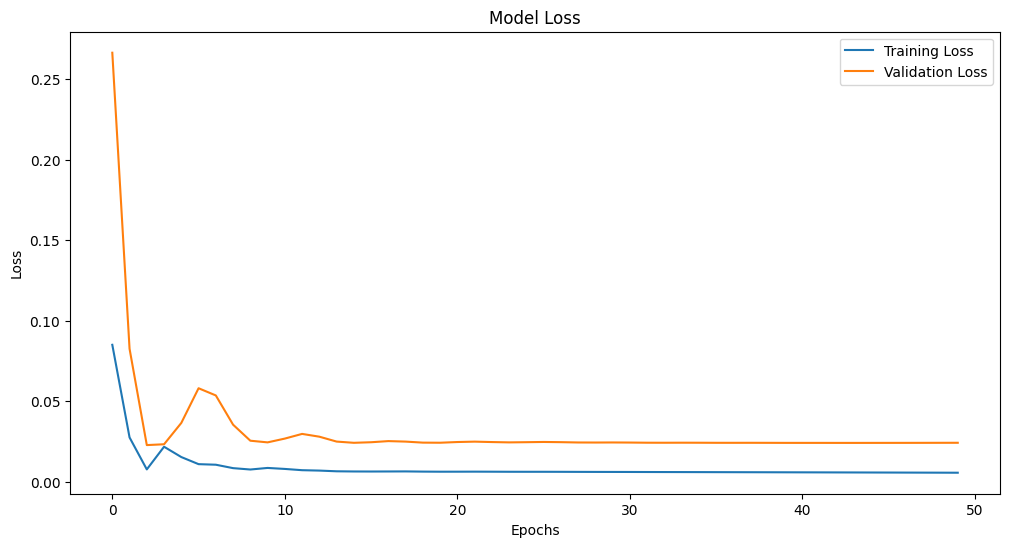

In [112]:
# 학습 과정 시각화
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [96]:
# 테스트 데이터 예측
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [97]:
# 예측값 역정규화
train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

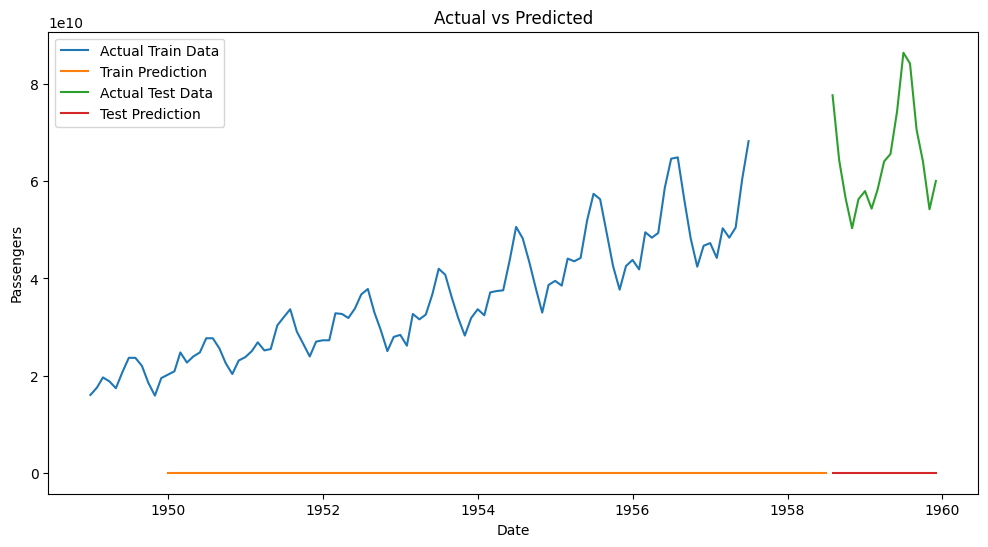

In [98]:
# 예측 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(df.index[:len(y_train)], y_train, label='Actual Train Data')
plt.plot(df.index[time_step:len(train_predict) + time_step], train_predict, label='Train Prediction')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], y_test, label='Actual Test Data')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], test_predict, label='Test Prediction')
plt.title('Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()